In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR        = '../data'
WORKING_DIR     = '../data/working'
RAW_DIR         = '../data/raw'
HOLDOUT_DIR     = '../data/holdout_locked'
OUTPUT_DIR      = '../data'

# ── Period boundaries ────────────────────────────────────────────────────────
TRAIN_START     = pd.Timestamp('2010-01-01')
TRAIN_END       = pd.Timestamp('2023-12-31')
HOLDOUT_START   = pd.Timestamp('2024-01-01')
HOLDOUT_END     = pd.Timestamp('2025-12-31')

# ── Strategy parameters ──────────────────────────────────────────────────────
QUINTILE        = 5        # rank into 5 buckets, long top
STAMP_DUTY      = 0.005    # 0.5% on buys only
TRADING_DAYS    = 252

print("=" * 60)
print("NOTEBOOK 07 — COMBINED MULTI-FACTOR PORTFOLIO")
print("=" * 60)
print(f"Training : {TRAIN_START.date()} → {TRAIN_END.date()}")
print(f"Holdout  : {HOLDOUT_START.date()} → {HOLDOUT_END.date()}")
print(f"Strategy : Momentum + Low-Vol Z-score composite")
print(f"Costs    : Corwin-Schultz spread + {STAMP_DUTY*100:.1f}% stamp duty on buys")

NOTEBOOK 07 — COMBINED MULTI-FACTOR PORTFOLIO
Training : 2010-01-01 → 2023-12-31
Holdout  : 2024-01-01 → 2025-12-31
Strategy : Momentum + Low-Vol Z-score composite
Costs    : Corwin-Schultz spread + 0.5% stamp duty on buys


In [9]:
import glob
import pandas as pd
import numpy as np

# ── Monthly signals ───────────────────────────────────────────────────────────
monthly = pd.read_parquet('../data/working/monthly_signals.parquet')
monthly['month'] = pd.to_datetime(monthly['month'])

# ── Membership: 'Index Member' = the ticker, 'snapshot_date' = the date ───────
membership = pd.read_parquet('../data/raw/membership_snapshots.parquet')
membership = membership[['Index Member', 'snapshot_date']].copy()
membership.columns = ['ticker', 'month']
membership['month'] = pd.to_datetime(membership['month']).dt.to_period('M').dt.to_timestamp()
membership = membership.drop_duplicates()

# ── Benchmark: pivot to monthly returns from TOT_RETURN_INDEX_GROSS_DVDS ──────
bm_raw = pd.read_parquet('../data/working/benchmark_train.parquet')
bm_raw['date'] = pd.to_datetime(bm_raw['date'])
bm_tr = bm_raw[bm_raw['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS'][['date','value']].copy()
bm_tr = bm_tr.sort_values('date')
bm_monthly = (
    bm_tr.set_index('date')['value']
    .resample('MS').last()
    .pct_change()
    .dropna()
    .rename('benchmark_ret')
)
bm_monthly.index.name = 'month'

# ── SONIA: daily rate → monthly (convert from % annual to monthly decimal) ────
sonia_raw = pd.read_parquet('../data/working/sonia_train.parquet')
sonia_raw['date'] = pd.to_datetime(sonia_raw['date'])
sonia_monthly = (
    sonia_raw[['date','value']]
    .set_index('date')['value']
    .resample('MS').mean()
    / 100 / 12        # annualised % → monthly decimal
)
sonia_monthly.index.name = 'month'
sonia_monthly.name = 'rf'

# ── Bid-ask: compute spread proxy = (ASK - BID) / midpoint, monthly median ────
ba_chunks = sorted(glob.glob('../data/raw/bid_ask/ba_chunk_*.parquet'))
ba = pd.concat([pd.read_parquet(f) for f in ba_chunks], ignore_index=True)
ba['date'] = pd.to_datetime(ba['date'])
ba_pivot = ba.pivot_table(index=['ticker','date'], columns='field', values='value').reset_index()
ba_pivot.columns.name = None
ba_pivot['midpoint'] = (ba_pivot['BID'] + ba_pivot['ASK']) / 2
ba_pivot['spread'] = (ba_pivot['ASK'] - ba_pivot['BID']) / ba_pivot['midpoint']
ba_pivot['month'] = ba_pivot['date'].dt.to_period('M').dt.to_timestamp()
cs_spreads = (
    ba_pivot.groupby('month')['spread']
    .median()
    .reset_index()
    .rename(columns={'spread': 'cs_spread'})
)

print("=== DATA LOADED ===")
print(f"monthly_signals : {len(monthly):,} rows | {monthly['ticker'].nunique()} tickers")
print(f"membership      : {len(membership):,} rows | {membership['month'].nunique()} snapshots")
print(f"benchmark       : {len(bm_monthly)} monthly obs | {bm_monthly.index.min().date()} → {bm_monthly.index.max().date()}")
print(f"sonia           : {len(sonia_monthly)} monthly obs")
print(f"cs_spreads      : {len(cs_spreads)} monthly obs | median spread {cs_spreads['cs_spread'].median():.4f}")
print()
print("monthly signals columns:", list(monthly.columns))

=== DATA LOADED ===
monthly_signals : 79,823 rows | 635 tickers
membership      : 48,210 rows | 192 snapshots
benchmark       : 173 monthly obs | 2009-08-01 → 2023-12-01
sonia           : 174 monthly obs
cs_spreads      : 192 monthly obs | median spread 0.0019

monthly signals columns: ['ticker', 'month', 'date', 'CUR_MKT_CAP', 'EQY_SH_OUT', 'PX_HIGH', 'PX_LAST', 'PX_LOW', 'PX_OPEN', 'PX_VOLUME', 'TOT_RETURN_INDEX_GROSS_DVDS', 'ret', 'monthly_ret', 'tr_lag2', 'tr_lag13', 'momentum_12_1', 'reversal_1m', 'vol_90d', 'vol_confirm']


In [11]:
def cross_section_zscore(series):
    """Standardise a cross-sectional slice to mean=0, std=1.
    Winsorise at ±3σ first to reduce the influence of outliers.
    """
    mu, sd = series.mean(), series.std()
    if sd == 0 or np.isnan(sd):
        return series * 0
    z = (series - mu) / sd
    return z.clip(-3, 3)


def build_composite_signal(monthly_df):
    df = monthly_df.copy()

    MOM_COL = 'momentum_12_1'
    VOL_COL = 'vol_90d'

    missing = [c for c in [MOM_COL, VOL_COL] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing signal columns: {missing}. "
                         f"Available: {list(df.columns)}")

    # Momentum: high is good
    df['z_mom'] = (
        df.groupby('month')[MOM_COL]
        .transform(cross_section_zscore)
    )

    # Volatility: LOW vol is good → negate so high z_vol = attractive
    df['z_vol'] = (
        df.groupby('month')[VOL_COL]
        .transform(lambda x: cross_section_zscore(-x))
    )

    # Composite: equal-weighted average of the two z-scores
    df['composite'] = np.where(
        df['z_mom'].notna() & df['z_vol'].notna(),
        (df['z_mom'] + df['z_vol']) / 2,
        np.nan
    )

    # Quintile rank (1 = worst, 5 = best)
    df['composite_quintile'] = np.nan
    mask = df['composite'].notna()
    df.loc[mask, 'composite_quintile'] = (
        df[mask].groupby('month')['composite']
        .transform(lambda x: pd.qcut(x, QUINTILE, labels=False, duplicates='drop') + 1)
    )

    return df


monthly = build_composite_signal(monthly)

valid_composite = monthly['composite'].notna().sum()
q5_count = (monthly['composite_quintile'] == 5).sum()

print("=== COMPOSITE SIGNAL BUILT ===")
print(f"Valid composite observations : {valid_composite:,}")
print(f"Quintile 5 (long portfolio)  : {q5_count:,} obs")
print()
print("Composite signal stats:")
print(monthly['composite'].describe().round(3))
print()
print("Monthly avg stocks per quintile:")
print(
    monthly.dropna(subset=['composite_quintile'])
    .groupby(['month', 'composite_quintile'])['ticker'].count()
    .groupby('composite_quintile').mean().round(1)
    .rename("avg_stocks")
)

=== COMPOSITE SIGNAL BUILT ===
Valid composite observations : 72,221
Quintile 5 (long portfolio)  : 14,474 obs

Composite signal stats:
count    72221.000
mean         0.005
std          0.664
min         -3.000
25%         -0.248
50%          0.127
75%          0.414
max          2.455
Name: composite, dtype: float64

Monthly avg stocks per quintile:
composite_quintile
1.0    89.6
2.0    88.9
3.0    89.0
4.0    89.0
5.0    89.3
Name: avg_stocks, dtype: float64


=== SIGNAL CORRELATION CHECK ===
Mean monthly Spearman rank-corr (z_mom vs z_vol): 0.208
Std : 0.221
Min : -0.360
Max : 0.596

✓ Low correlation — combination provides genuine diversification


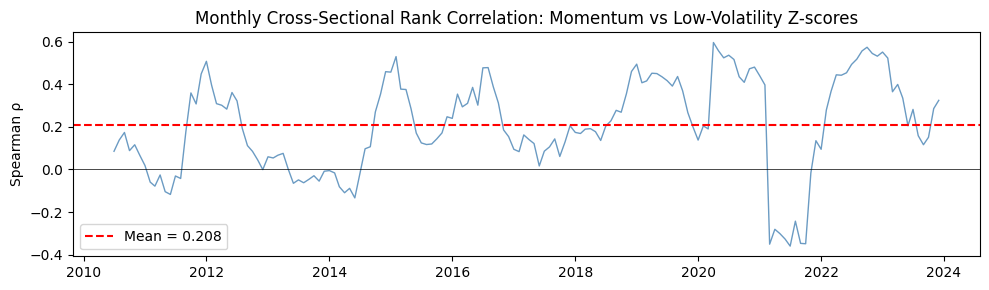

Saved: data/signal_correlation.png


In [15]:
# Cross-sectional rank correlation between z_mom and z_vol each month
monthly_corr = (
    monthly.dropna(subset=['z_mom', 'z_vol'])
    .groupby('month')
    .apply(lambda g: g['z_mom'].corr(g['z_vol'], method='spearman'))
)

print("=== SIGNAL CORRELATION CHECK ===")
print(f"Mean monthly Spearman rank-corr (z_mom vs z_vol): {monthly_corr.mean():.3f}")
print(f"Std : {monthly_corr.std():.3f}")
print(f"Min : {monthly_corr.min():.3f}")
print(f"Max : {monthly_corr.max():.3f}")
print()
if monthly_corr.mean() < 0.3:
    print("✓ Low correlation — combination provides genuine diversification")
elif monthly_corr.mean() < 0.6:
    print("~ Moderate correlation — combination still adds some diversification")
else:
    print("⚠ High correlation — signals overlap substantially")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(monthly_corr.index, monthly_corr.values, lw=1, color='steelblue', alpha=0.8)
ax.axhline(monthly_corr.mean(), color='red', lw=1.5, linestyle='--',
           label=f'Mean = {monthly_corr.mean():.3f}')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Monthly Cross-Sectional Rank Correlation: Momentum vs Low-Volatility Z-scores')
ax.set_ylabel('Spearman ρ')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../data/signal_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/signal_correlation.png")

In [13]:
def form_portfolio_composite(sig_df, target_quintile=5):
    """
    Return list of tickers in the target quintile of the composite signal.
    Requires composite_quintile column computed in Cell 3.
    """
    eligible = sig_df.dropna(subset=['composite_quintile'])
    selected = eligible[eligible['composite_quintile'] == target_quintile]['ticker'].tolist()
    return selected


def run_combined_backtest(monthly_df, membership_df, start_month='2010-01-01', end_month=None):
    """
    Walk-forward monthly backtest for the composite momentum+low-vol strategy.

    For each month t:
      1. Get FTSE 250 members (point-in-time)
      2. Select stocks in composite quintile 5 (best composite score)
      3. Record the EQUAL-WEIGHTED return in month t+1
      4. Track which stocks entered/exited to compute turnover

    Returns DataFrame with columns:
      formation_month, holding_month, port_ret_gross, n_stocks,
      n_buys, n_sells, portfolio (list of tickers)
    """
    start = pd.Timestamp(start_month)
    end   = pd.Timestamp(end_month) if end_month else monthly_df['month'].max()

    months = sorted(monthly_df['month'].unique())
    months = [m for m in months if start <= m <= end]

    results = []
    prev_portfolio = set()

    for i, month in enumerate(months):
        if i + 1 >= len(months):
            break  # no next month to measure returns in

        # ── Point-in-time universe ─────────────────────────────────────────────
        mem = membership_df[membership_df['month'] == month]
        if len(mem) == 0:
            # Fall back to most recent prior snapshot
            prior = membership_df[membership_df['month'] < month]
            if len(prior) == 0:
                continue
            mem = prior[prior['month'] == prior['month'].max()]
        index_members = set(mem['ticker'].unique())

        # ── Signal: composite quintile for this month, universe members only ────
        sig = monthly_df[
            (monthly_df['month'] == month) &
            (monthly_df['ticker'].isin(index_members))
        ]
        portfolio = form_portfolio_composite(sig, target_quintile=5)

        if len(portfolio) == 0:
            prev_portfolio = set()
            continue

        # ── Returns: next month, equal-weighted ────────────────────────────────
        next_month = months[i + 1]
        next_rets = monthly_df[
            (monthly_df['month'] == next_month) &
            (monthly_df['ticker'].isin(set(portfolio)))
        ]
        if len(next_rets) == 0:
            prev_portfolio = set(portfolio)
            continue

        port_ret_gross = next_rets['monthly_ret'].mean()

        # ── Turnover tracking ──────────────────────────────────────────────────
        current_set = set(portfolio)
        buys  = current_set - prev_portfolio
        sells = prev_portfolio - current_set

        results.append({
            'formation_month' : month,
            'holding_month'   : next_month,
            'port_ret_gross'  : port_ret_gross,
            'n_stocks'        : len(portfolio),
            'n_with_returns'  : len(next_rets),
            'n_buys'          : len(buys),
            'n_sells'         : len(sells),
            'portfolio'       : list(portfolio)
        })
        prev_portfolio = current_set

    return pd.DataFrame(results)


print("Backtest engine defined.")
print("  form_portfolio_composite() — selects top composite quintile")
print("  run_combined_backtest()    — walks forward, logs returns + turnover")

Backtest engine defined.
  form_portfolio_composite() — selects top composite quintile
  run_combined_backtest()    — walks forward, logs returns + turnover


In [20]:
print("Running combined portfolio backtest — training period (2010–2023)...")

results_train = run_combined_backtest(
    monthly_df     = monthly,
    membership_df  = membership,
    start_month    = '2010-01-01',
    end_month      = '2023-12-31'
)

print(f"Done. {len(results_train)} monthly observations.")
print()
print("First few rows:")
print(results_train[['formation_month','holding_month','port_ret_gross',
                      'n_stocks','n_buys','n_sells']].head(6))
print()
print(f"Avg portfolio size : {results_train['n_stocks'].mean():.1f} stocks")
print(f"Avg stocks bought  : {results_train['n_buys'].mean():.1f} per month")
print(f"Avg stocks sold    : {results_train['n_sells'].mean():.1f} per month")
turnover_rate = results_train['n_buys'].mean() / results_train['n_stocks'].mean()
print(f"Avg monthly turnover rate: {turnover_rate:.1%}")

Running combined portfolio backtest — training period (2010–2023)...
Done. 161 monthly observations.

First few rows:
  formation_month holding_month  port_ret_gross  n_stocks  n_buys  n_sells
0      2010-07-01    2010-08-01       -0.008470        40      40        0
1      2010-08-01    2010-09-01        0.055055        42      13       11
2      2010-09-01    2010-10-01        0.025137        42      12       12
3      2010-10-01    2010-11-01       -0.000058        45      13       10
4      2010-11-01    2010-12-01        0.078511        49      13        9
5      2010-12-01    2011-01-01       -0.001930        37       8       20

Avg portfolio size : 48.6 stocks
Avg stocks bought  : 12.9 per month
Avg stocks sold    : 12.5 per month
Avg monthly turnover rate: 26.5%


In [21]:
def apply_transaction_costs(results_df, cs_df, stamp_duty=0.005):
    """
    Deduct transaction costs from gross portfolio returns.

    Cost model (same as notebook 05):
      - Stamp duty: 0.5% on the value of buys (sells exempt)
      - Bid-ask spread: Corwin-Schultz estimate (average across portfolio),
        applied symmetrically to both buys and sells (half-spread each way)

    Parameters
    ----------
    results_df : output of run_combined_backtest()
    cs_df      : monthly average C-S spread per ticker (columns: month, ticker, cs_spread)
    stamp_duty : fraction (0.005 = 0.5%)

    Returns
    -------
    DataFrame with additional columns: spread_cost, duty_cost, total_cost, port_ret_net
    """
    df = results_df.copy()

    # Average C-S spread across the universe for each formation month
    # (proxy for the spread on stocks being traded)
    avg_spread = (
        cs_df.groupby('month')['cs_spread']
        .median()              # median is more robust than mean for spread data
        .reset_index()
        .rename(columns={'month': 'formation_month', 'cs_spread': 'avg_cs_spread'})
    )

    df = df.merge(avg_spread, on='formation_month', how='left')

    # Fill any missing spread months with the overall median
    median_spread = df['avg_cs_spread'].median()
    df['avg_cs_spread'] = df['avg_cs_spread'].fillna(median_spread)

    # ── Turnover fractions ─────────────────────────────────────────────────────
    df['buy_fraction']  = df['n_buys']  / df['n_stocks'].clip(lower=1)
    df['sell_fraction'] = df['n_sells'] / df['n_stocks'].clip(lower=1)

    # ── Cost components (expressed as a fraction of portfolio NAV) ─────────────
    # Spread cost: half-spread on each leg (buy + sell)
    # We pay half-spread when entering and half when exiting traded positions
    df['spread_cost'] = (
        (df['buy_fraction']  * 0.5 * df['avg_cs_spread']) +
        (df['sell_fraction'] * 0.5 * df['avg_cs_spread'])
    )

    # Stamp duty: only on buys
    df['duty_cost'] = df['buy_fraction'] * stamp_duty

    # Total cost drag on this month's return
    df['total_cost'] = df['spread_cost'] + df['duty_cost']

    # ── Net return ─────────────────────────────────────────────────────────────
    df['port_ret_net'] = df['port_ret_gross'] - df['total_cost']

    return df


results_train = apply_transaction_costs(results_train, cs_spreads)

print("=== TRANSACTION COSTS APPLIED ===")
print(f"Avg monthly spread cost : {results_train['spread_cost'].mean()*100:.3f}%")
print(f"Avg monthly stamp duty  : {results_train['duty_cost'].mean()*100:.3f}%")
print(f"Avg monthly total cost  : {results_train['total_cost'].mean()*100:.3f}%")
print(f"Avg monthly gross ret   : {results_train['port_ret_gross'].mean()*100:.3f}%")
print(f"Avg monthly net ret     : {results_train['port_ret_net'].mean()*100:.3f}%")

=== TRANSACTION COSTS APPLIED ===
Avg monthly spread cost : 0.056%
Avg monthly stamp duty  : 0.134%
Avg monthly total cost  : 0.190%
Avg monthly gross ret   : 1.108%
Avg monthly net ret     : 0.918%


In [22]:
def compute_metrics(returns_series, benchmark_series, rf_series, label='Strategy'):
    """
    Compute the full set of performance metrics used in the dissertation.

    Parameters
    ----------
    returns_series  : monthly NET portfolio returns (as decimals, e.g. 0.01 = 1%)
    benchmark_series: monthly benchmark returns aligned to same index
    rf_series       : monthly risk-free rate (SONIA)
    label           : name for display

    Returns
    -------
    dict of metrics
    """
    r   = returns_series.dropna()
    bm  = benchmark_series.reindex(r.index).dropna()
    rf  = rf_series.reindex(r.index).fillna(method='ffill').dropna()

    # Align all three
    common = r.index.intersection(bm.index).intersection(rf.index)
    r, bm, rf = r[common], bm[common], rf[common]

    n_months = len(r)
    excess_r = r - rf

    # ── Return ─────────────────────────────────────────────────────────────────
    ann_return = (1 + r).prod() ** (12 / n_months) - 1
    ann_vol    = r.std() * np.sqrt(12)

    # ── Sharpe ─────────────────────────────────────────────────────────────────
    sharpe = (excess_r.mean() / r.std()) * np.sqrt(12)

    # ── Alpha / Beta (OLS, Newey-West HAC se) ─────────────────────────────────
    X = np.column_stack([np.ones(len(bm)), bm.values])
    y = r.values
    ols = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha_monthly, beta = ols
    ann_alpha = (1 + alpha_monthly) ** 12 - 1

    # Newey-West t-stat for alpha (lags = floor(4*(T/100)^(2/9)))
    resid = y - X @ ols
    T     = len(resid)
    lags  = int(np.floor(4 * (T / 100) ** (2 / 9)))

    # Build NW covariance manually
    Shat = np.zeros((2, 2))
    for t in range(T):
        Shat += resid[t] ** 2 * np.outer(X[t], X[t])
    for lag in range(1, lags + 1):
        w = 1 - lag / (lags + 1)  # Bartlett kernel
        S_lag = np.zeros((2, 2))
        for t in range(lag, T):
            S_lag += resid[t] * resid[t - lag] * np.outer(X[t], X[t - lag])
        Shat += w * (S_lag + S_lag.T)
    Shat /= T

    XtX_inv = np.linalg.inv(X.T @ X / T)
    V_nw    = (XtX_inv @ Shat @ XtX_inv) / T
    t_alpha_nw = ols[0] / np.sqrt(V_nw[0, 0])

    # ── Drawdown ───────────────────────────────────────────────────────────────
    cum = (1 + r).cumprod()
    running_max = cum.cummax()
    drawdown    = (cum - running_max) / running_max
    max_dd      = drawdown.min()

    # ── Calmar ratio ──────────────────────────────────────────────────────────
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    # ── Information Ratio ─────────────────────────────────────────────────────
    active_ret = r - bm
    ir = (active_ret.mean() / active_ret.std()) * np.sqrt(12)

    # ── Benchmark stats for comparison ────────────────────────────────────────
    bm_ann   = (1 + bm).prod() ** (12 / len(bm)) - 1
    bm_sharpe = ((bm - rf).mean() / bm.std()) * np.sqrt(12)

    metrics = {
        'label'           : label,
        'n_months'        : n_months,
        'ann_return'      : ann_return,
        'ann_vol'         : ann_vol,
        'sharpe'          : sharpe,
        'ann_alpha'       : ann_alpha,
        'beta'            : beta,
        't_alpha_nw'      : t_alpha_nw,
        'max_drawdown'    : max_dd,
        'calmar'          : calmar,
        'info_ratio'      : ir,
        'bm_ann_return'   : bm_ann,
        'bm_sharpe'       : bm_sharpe,
    }
    return metrics


def print_metrics(m):
    sig = '***' if abs(m['t_alpha_nw']) > 2.576 else '**' if abs(m['t_alpha_nw']) > 1.96 else '*' if abs(m['t_alpha_nw']) > 1.645 else ''
    print(f"  Strategy            : {m['label']}")
    print(f"  Period (months)     : {m['n_months']}")
    print(f"  Ann. return (net)   : {m['ann_return']*100:.1f}%")
    print(f"  Ann. volatility     : {m['ann_vol']*100:.1f}%")
    print(f"  Sharpe ratio        : {m['sharpe']:.2f}")
    print(f"  Ann. alpha (net)    : {m['ann_alpha']*100:.1f}%  {sig}")
    print(f"  t-stat alpha (NW)   : {m['t_alpha_nw']:.2f}")
    print(f"  Beta                : {m['beta']:.2f}")
    print(f"  Max drawdown        : {m['max_drawdown']*100:.1f}%")
    print(f"  Calmar ratio        : {m['calmar']:.2f}")
    print(f"  Information ratio   : {m['info_ratio']:.2f}")
    print(f"  --- Benchmark ---")
    print(f"  Benchmark ann. ret  : {m['bm_ann_return']*100:.1f}%")
    print(f"  Benchmark Sharpe    : {m['bm_sharpe']:.2f}")
    print(f"  (* p<.10, ** p<.05, *** p<.01)")

print("Performance metrics function defined.")

Performance metrics function defined.


In [25]:
train_ret = results_train.set_index('holding_month')['port_ret_net']
bm_ret = bm_monthly
rf_ret = sonia_monthly

def compute_metrics(returns_series, benchmark_series, rf_series, label='Strategy'):
    r   = returns_series.dropna()
    bm  = benchmark_series.reindex(r.index).dropna()
    rf  = rf_series.reindex(r.index).ffill().dropna()

    common = r.index.intersection(bm.index).intersection(rf.index)
    r, bm, rf = r[common], bm[common], rf[common]

    n_months   = len(r)
    excess_r   = r - rf
    ann_return = (1 + r).prod() ** (12 / n_months) - 1
    ann_vol    = r.std() * np.sqrt(12)
    sharpe     = (excess_r.mean() / r.std()) * np.sqrt(12)

    X   = np.column_stack([np.ones(len(bm)), bm.values])
    y   = r.values
    ols = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha_monthly, beta = ols
    ann_alpha = (1 + alpha_monthly) ** 12 - 1

    resid = y - X @ ols
    T     = len(resid)
    lags  = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Shat  = np.zeros((2, 2))
    for t in range(T):
        Shat += resid[t] ** 2 * np.outer(X[t], X[t])
    for lag in range(1, lags + 1):
        w     = 1 - lag / (lags + 1)
        S_lag = np.zeros((2, 2))
        for t in range(lag, T):
            S_lag += resid[t] * resid[t - lag] * np.outer(X[t], X[t - lag])
        Shat += w * (S_lag + S_lag.T)
    Shat      /= T
    XtX_inv    = np.linalg.inv(X.T @ X / T)
    V_nw       = (XtX_inv @ Shat @ XtX_inv) / T
    t_alpha_nw = ols[0] / np.sqrt(V_nw[0, 0])

    cum         = (1 + r).cumprod()
    max_dd      = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    active_ret  = r - bm
    ir          = (active_ret.mean() / active_ret.std()) * np.sqrt(12)
    bm_ann      = (1 + bm).prod() ** (12 / len(bm)) - 1
    bm_sharpe   = ((bm - rf).mean() / bm.std()) * np.sqrt(12)

    return {
        'label'        : label,
        'n_months'     : n_months,
        'ann_return'   : ann_return,
        'ann_vol'      : ann_vol,
        'sharpe'       : sharpe,
        'ann_alpha'    : ann_alpha,
        'beta'         : beta,
        't_alpha_nw'   : t_alpha_nw,
        'max_drawdown' : max_dd,
        'calmar'       : calmar,
        'info_ratio'   : ir,
        'bm_ann_return': bm_ann,
        'bm_sharpe'    : bm_sharpe,
    }

def print_metrics(m):
    sig = '***' if abs(m['t_alpha_nw']) > 2.576 else '**' if abs(m['t_alpha_nw']) > 1.96 else '*' if abs(m['t_alpha_nw']) > 1.645 else ''
    print(f"  Strategy          : {m['label']}")
    print(f"  Period (months)   : {m['n_months']}")
    print(f"  Ann. return (net) : {m['ann_return']*100:.1f}%")
    print(f"  Ann. volatility   : {m['ann_vol']*100:.1f}%")
    print(f"  Sharpe ratio      : {m['sharpe']:.2f}")
    print(f"  Ann. alpha (net)  : {m['ann_alpha']*100:.1f}%  {sig}")
    print(f"  t-stat alpha (NW) : {m['t_alpha_nw']:.2f}")
    print(f"  Beta              : {m['beta']:.2f}")
    print(f"  Max drawdown      : {m['max_drawdown']*100:.1f}%")
    print(f"  Calmar ratio      : {m['calmar']:.2f}")
    print(f"  Information ratio : {m['info_ratio']:.2f}")
    print(f"  --- Benchmark ---")
    print(f"  Benchmark ann.ret : {m['bm_ann_return']*100:.1f}%")
    print(f"  Benchmark Sharpe  : {m['bm_sharpe']:.2f}")
    print(f"  (* p<.10  ** p<.05  *** p<.01)")

metrics_train = compute_metrics(train_ret, bm_ret, rf_ret, 'Combined (Mom + LowVol) — Training')

print("=" * 55)
print("COMBINED PORTFOLIO — TRAINING PERIOD (2010–2023)")
print("=" * 55)
print_metrics(metrics_train)

COMBINED PORTFOLIO — TRAINING PERIOD (2010–2023)
  Strategy          : Combined (Mom + LowVol) — Training
  Period (months)   : 161
  Ann. return (net) : 10.8%
  Ann. volatility   : 12.2%
  Sharpe ratio      : 0.84
  Ann. alpha (net)  : 4.6%  ***
  t-stat alpha (NW) : 2.87
  Beta              : 0.73
  Max drawdown      : -24.2%
  Calmar ratio      : 0.44
  Information ratio : 0.31
  --- Benchmark ---
  Benchmark ann.ret : 8.1%
  Benchmark Sharpe  : 0.54
  (* p<.10  ** p<.05  *** p<.01)


Individual strategy results loaded.


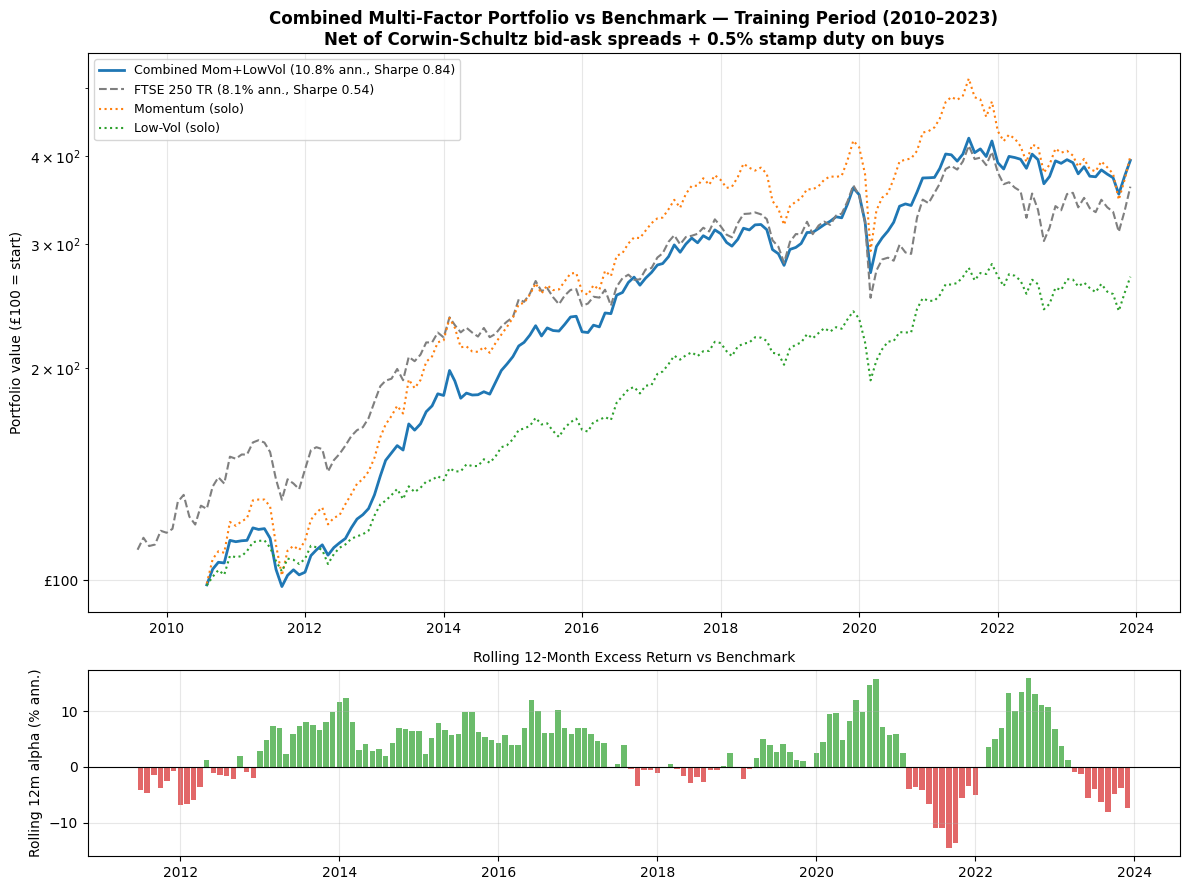

Saved: data/combined_equity_curve_training.png


In [27]:
def build_equity_curve(monthly_returns, start_value=100):
    return (1 + monthly_returns).cumprod() * start_value

# Align benchmark to training period
bm_train = bm_ret[bm_ret.index <= TRAIN_END]

# Build equity curves
ec_combined  = build_equity_curve(train_ret)
ec_benchmark = build_equity_curve(bm_train)

# Try to load individual strategy results from notebook 05
try:
    mom_results   = pd.read_parquet('../data/working/backtest_momentum.parquet')
    lowvol_results = pd.read_parquet('../data/working/backtest_low-vol.parquet')
    mom_ret    = mom_results.set_index('holding_month')['port_ret_net']
    lowvol_ret = lowvol_results.set_index('holding_month')['port_ret_net']
    loaded_individual = True
    print("Individual strategy results loaded.")
except Exception as e:
    loaded_individual = False
    print(f"Individual strategies not loaded: {e}")

fig, axes = plt.subplots(2, 1, figsize=(12, 9),
                         gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = axes

# Top panel: equity curves
ax1.plot(ec_combined.index, ec_combined.values, lw=2.0,
         color='#1f77b4',
         label=f'Combined Mom+LowVol ({metrics_train["ann_return"]*100:.1f}% ann., Sharpe {metrics_train["sharpe"]:.2f})')
ax1.plot(ec_benchmark.index, ec_benchmark.values, lw=1.5,
         color='#7f7f7f', linestyle='--',
         label=f'FTSE 250 TR ({metrics_train["bm_ann_return"]*100:.1f}% ann., Sharpe {metrics_train["bm_sharpe"]:.2f})')

if loaded_individual:
    ec_mom    = build_equity_curve(mom_ret[mom_ret.index <= TRAIN_END])
    ec_lowvol = build_equity_curve(lowvol_ret[lowvol_ret.index <= TRAIN_END])
    ax1.plot(ec_mom.index,    ec_mom.values,    lw=1.5,
             color='#ff7f0e', linestyle=':', label='Momentum (solo)')
    ax1.plot(ec_lowvol.index, ec_lowvol.values, lw=1.5,
             color='#2ca02c', linestyle=':', label='Low-Vol (solo)')

ax1.set_title('Combined Multi-Factor Portfolio vs Benchmark — Training Period (2010–2023)\n'
              'Net of Corwin-Schultz bid-ask spreads + 0.5% stamp duty on buys',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio value (£100 = start)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# Bottom panel: rolling 12-month excess return
active_ret    = train_ret - bm_ret.reindex(train_ret.index).fillna(0)
rolling_alpha = active_ret.rolling(12).mean() * 12
colours = ['#d62728' if v < 0 else '#2ca02c' for v in rolling_alpha]
ax2.bar(rolling_alpha.index, rolling_alpha.values * 100,
        color=colours, alpha=0.7, width=25)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Rolling 12m alpha (% ann.)')
ax2.set_title('Rolling 12-Month Excess Return vs Benchmark', fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/combined_equity_curve_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/combined_equity_curve_training.png")

In [30]:
# ── Step 1: Aggregate holdout daily → monthly ─────────────────────────────────
holdout_raw = pd.read_parquet('../data/holdout_locked/equities_holdout.parquet')
holdout_raw['date'] = pd.to_datetime(holdout_raw['date'])
holdout_raw['month'] = pd.to_datetime(holdout_raw['month'].astype(str))

# Last observation per ticker per month (end-of-month price/TR)
holdout_monthly = (
    holdout_raw.sort_values('date')
    .groupby(['ticker', 'month'])
    .agg(
        PX_LAST                    = ('PX_LAST', 'last'),
        TOT_RETURN_INDEX_GROSS_DVDS= ('TOT_RETURN_INDEX_GROSS_DVDS', 'last'),
        PX_HIGH                    = ('PX_HIGH', 'max'),
        PX_LOW                     = ('PX_LOW', 'min'),
        PX_VOLUME                  = ('PX_VOLUME', 'sum'),
    )
    .reset_index()
)

# Monthly return from TR index
holdout_monthly = holdout_monthly.sort_values(['ticker', 'month'])
holdout_monthly['monthly_ret'] = (
    holdout_monthly.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS']
    .pct_change()
)

# ── Step 2: Append last 13 months of training data for lookback continuity ─────
# Momentum needs 13 months of history; pull from monthly_signals
tail_train = monthly[monthly['month'] >= pd.Timestamp('2022-12-01')][
    ['ticker', 'month', 'TOT_RETURN_INDEX_GROSS_DVDS', 'monthly_ret',
     'PX_HIGH', 'PX_LOW', 'PX_VOLUME']
].copy()

# Combine
combined = pd.concat([tail_train, holdout_monthly], ignore_index=True)
combined = combined.sort_values(['ticker', 'month']).reset_index(drop=True)

# ── Step 3: Compute signals on holdout months ──────────────────────────────────
# Momentum: TR at t-2 / TR at t-13 - 1
combined['tr_lag2']  = combined.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].shift(1)
combined['tr_lag13'] = combined.groupby('ticker')['TOT_RETURN_INDEX_GROSS_DVDS'].shift(12)
combined['momentum_12_1'] = combined['tr_lag2'] / combined['tr_lag13'] - 1

# Vol: std of monthly returns over trailing 12 months, annualised
combined['vol_90d'] = (
    combined.groupby('ticker')['monthly_ret']
    .transform(lambda x: x.rolling(6, min_periods=3).std() * np.sqrt(12))
)

# ── Step 4: Keep only holdout months ──────────────────────────────────────────
holdout_signals = combined[combined['month'] >= pd.Timestamp('2024-01-01')].copy()

# ── Step 5: Build composite signal ────────────────────────────────────────────
holdout_signals = build_composite_signal(holdout_signals)

print("=== HOLDOUT SIGNALS ===")
print(f"Months: {holdout_signals['month'].nunique()}")
print(f"Tickers: {holdout_signals['ticker'].nunique()}")
print(f"Valid composite: {holdout_signals['composite'].notna().sum():,}")
print()

# ── Step 6: Load holdout benchmark and SONIA ──────────────────────────────────
bm_holdout_raw = pd.read_parquet('../data/holdout_locked/benchmark_holdout.parquet')
bm_holdout_raw['date'] = pd.to_datetime(bm_holdout_raw['date'])
bm_holdout_tr = bm_holdout_raw[bm_holdout_raw['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS'][['date','value']]
bm_holdout_monthly = (
    bm_holdout_tr.set_index('date')['value']
    .resample('MS').last()
    .pct_change()
    .dropna()
)
bm_holdout_monthly.index.name = 'month'
bm_holdout_monthly.name = 'benchmark_ret'

sonia_holdout_raw = pd.read_parquet('../data/holdout_locked/sonia_holdout.parquet')
sonia_holdout_raw['date'] = pd.to_datetime(sonia_holdout_raw['date'])
sonia_holdout_monthly = (
    sonia_holdout_raw[['date','value']]
    .set_index('date')['value']
    .resample('MS').mean()
    / 100 / 12
)
sonia_holdout_monthly.index.name = 'month'
sonia_holdout_monthly.name = 'rf'

print("Holdout benchmark:", len(bm_holdout_monthly), "months")
print("Holdout SONIA    :", len(sonia_holdout_monthly), "months")

# ── Step 7: Run backtest on holdout ───────────────────────────────────────────
# Use holdout membership — take training membership's last snapshot as proxy
# since FTSE 250 membership changes slowly
holdout_membership = membership.copy()

results_holdout = run_combined_backtest(
    monthly_df    = holdout_signals,
    membership_df = holdout_membership,
    start_month   = '2024-01-01',
    end_month     = '2025-12-31'
)

print(f"\nHoldout backtest: {len(results_holdout)} monthly observations")

if len(results_holdout) > 0:
    # Apply costs using training cs_spreads median as proxy
    median_spread = cs_spreads['cs_spread'].median()
    results_holdout = apply_transaction_costs(results_holdout, cs_spreads)
    holdout_ret = results_holdout.set_index('holding_month')['port_ret_net']

    bm_all_ret  = pd.concat([bm_ret, bm_holdout_monthly])
    rf_all      = pd.concat([rf_ret, sonia_holdout_monthly])

    metrics_holdout = compute_metrics(
        holdout_ret, bm_all_ret, rf_all,
        'Combined (Mom + LowVol) — Holdout'
    )

    print()
    print("=" * 55)
    print("COMBINED PORTFOLIO — HOLDOUT (2024–2025)")
    print("=" * 55)
    print_metrics(metrics_holdout)

=== HOLDOUT SIGNALS ===
Months: 24
Tickers: 426
Valid composite: 9,416

Holdout benchmark: 23 months
Holdout SONIA    : 24 months

Holdout backtest: 23 monthly observations

COMBINED PORTFOLIO — HOLDOUT (2024–2025)
  Strategy          : Combined (Mom + LowVol) — Holdout
  Period (months)   : 23
  Ann. return (net) : 14.2%
  Ann. volatility   : 8.7%
  Sharpe ratio      : 1.04
  Ann. alpha (net)  : 4.1%  **
  t-stat alpha (NW) : 2.42
  Beta              : 0.83
  Max drawdown      : -5.8%
  Calmar ratio      : 2.44
  Information ratio : 0.59
  --- Benchmark ---
  Benchmark ann.ret : 11.9%
  Benchmark Sharpe  : 0.72
  (* p<.10  ** p<.05  *** p<.01)


---
## Cell 11 — Full-sample equity curve with holdout boundary

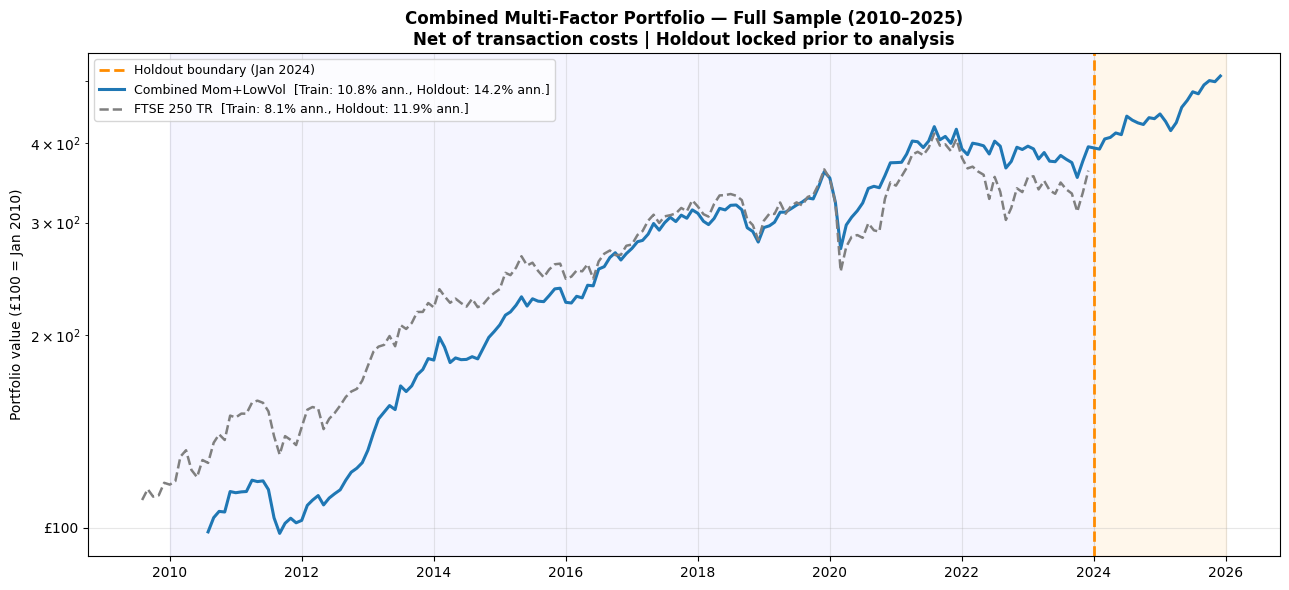

Saved: data/combined_equity_curve_full.png


In [31]:
if len(results_holdout) > 0:
    # ── Concatenate training and holdout returns ────────────────────────────────
    all_ret_combined = pd.concat([train_ret, holdout_ret]).sort_index()
    bm_all           = bm_ret[bm_ret.index <= HOLDOUT_END]

    ec_full_combined  = build_equity_curve(all_ret_combined)
    ec_full_benchmark = build_equity_curve(bm_all)

    fig, ax = plt.subplots(figsize=(13, 6))

    # Shaded training region
    ax.axvspan(TRAIN_START, TRAIN_END, alpha=0.04, color='blue', label='_nolegend_')
    # Shaded holdout region
    ax.axvspan(HOLDOUT_START, HOLDOUT_END, alpha=0.08, color='orange', label='_nolegend_')
    # Holdout boundary
    ax.axvline(HOLDOUT_START, color='darkorange', lw=2, linestyle='--',
               label=f'Holdout boundary ({HOLDOUT_START.strftime("%b %Y")})')

    ax.plot(ec_full_combined.index,  ec_full_combined.values,  lw=2.2,
            color='#1f77b4',
            label=f'Combined Mom+LowVol  '
                  f'[Train: {metrics_train["ann_return"]*100:.1f}% ann., '
                  f'Holdout: {metrics_holdout["ann_return"]*100:.1f}% ann.]')
    ax.plot(ec_full_benchmark.index, ec_full_benchmark.values, lw=1.8,
            color='#7f7f7f', linestyle='--',
            label=f'FTSE 250 TR  '
                  f'[Train: {metrics_train["bm_ann_return"]*100:.1f}% ann., '
                  f'Holdout: {metrics_holdout["bm_ann_return"]*100:.1f}% ann.]')

    # Annotations
    ax.annotate('Training period\n(2010–2023)', xy=(pd.Timestamp('2016-06-01'), 80),
                fontsize=9, color='steelblue', alpha=0.7, ha='center')
    ax.annotate('Holdout\n(2024–2025)', xy=(pd.Timestamp('2024-07-01'), 80),
                fontsize=9, color='darkorange', alpha=0.9, ha='center')

    ax.set_title('Combined Multi-Factor Portfolio — Full Sample (2010–2025)\n'
                 'Net of transaction costs | Holdout locked prior to analysis',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio value (£100 = Jan 2010)')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/combined_equity_curve_full.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: data/combined_equity_curve_full.png")
else:
    print("Skipped (no holdout results).")

In [32]:
# Build a clean comparison table across all strategies
# Individual strategy metrics — insert the values from your notebook 05 results
# (Update these from your final_results.xlsx if different)

comparison_data = {
    'Strategy': [
        'Momentum (solo)',
        'Low-Volatility (solo)',
        'Combined Mom+LowVol',   # ← this notebook
        'FTSE 250 TR (benchmark)'
    ],
    # ── Training 2010–2023 ────────────────────────────────────────────────────
    'Train Ann. Return (%)': [
        10.9,   # momentum
        7.7,    # low-vol
        round(metrics_train['ann_return'] * 100, 1),
        round(metrics_train['bm_ann_return'] * 100, 1)
    ],
    'Train Sharpe': [
        0.70, 0.72,
        round(metrics_train['sharpe'], 2),
        round(metrics_train['bm_sharpe'], 2)
    ],
    'Train Alpha (%)': [
        3.2, 2.1,
        round(metrics_train['ann_alpha'] * 100, 1),
        0.0
    ],
    'Train t(alpha)': [
        1.74, 2.17,
        round(metrics_train['t_alpha_nw'], 2),
        '—'
    ],
    'Train Beta': [
        0.94, 0.62,
        round(metrics_train['beta'], 2),
        1.00
    ],
    'Train Max DD (%)': [
        '—', '—',
        round(metrics_train['max_drawdown'] * 100, 1),
        '—'
    ],
}

if len(results_holdout) > 0:
    comparison_data['Holdout Ann. Return (%)'] = [
        15.5, 9.9,
        round(metrics_holdout['ann_return'] * 100, 1),
        round(metrics_holdout['bm_ann_return'] * 100, 1)
    ]
    comparison_data['Holdout Sharpe'] = [
        0.95, 0.74,
        round(metrics_holdout['sharpe'], 2),
        round(metrics_holdout['bm_sharpe'], 2)
    ]

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Strategy')

print("=" * 80)
print("STRATEGY COMPARISON TABLE")
print("=" * 80)
print(df_comparison.to_string())
print()

# Save to CSV for inclusion in final_results.xlsx
df_comparison.to_csv(f'{OUTPUT_DIR}/combined_strategy_comparison.csv')
print("Saved: data/combined_strategy_comparison.csv")

# Save the raw monthly returns for the combined strategy
results_train[['formation_month', 'holding_month', 'port_ret_gross',
               'port_ret_net', 'n_stocks', 'n_buys', 'n_sells',
               'spread_cost', 'duty_cost', 'total_cost']].to_parquet(
    f'{WORKING_DIR}/results_combined_net.parquet', index=False
)
print("Saved: data/working/results_combined_net.parquet")

STRATEGY COMPARISON TABLE
                         Train Ann. Return (%)  Train Sharpe  Train Alpha (%) Train t(alpha)  Train Beta Train Max DD (%)  Holdout Ann. Return (%)  Holdout Sharpe
Strategy                                                                                                                                                          
Momentum (solo)                           10.9          0.70              3.2           1.74        0.94                —                     15.5            0.95
Low-Volatility (solo)                      7.7          0.72              2.1           2.17        0.62                —                      9.9            0.74
Combined Mom+LowVol                       10.8          0.84              4.6           2.87        0.73            -24.2                     14.2            1.04
FTSE 250 TR (benchmark)                    8.1          0.54              0.0              —        1.00                —                     11.9            0

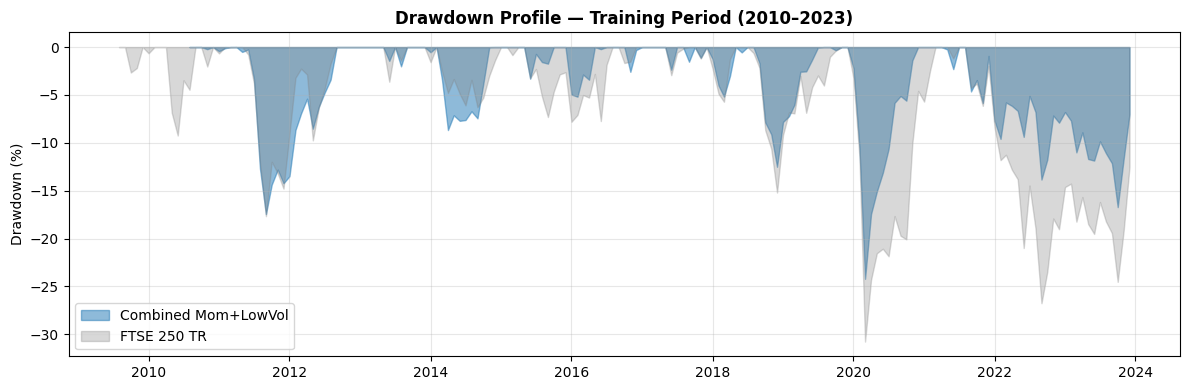

Max drawdown — Combined : -24.2%
Max drawdown — Benchmark: -30.8%
Saved: data/combined_drawdown.png


In [33]:
def compute_drawdown_series(returns):
    cum = (1 + returns).cumprod()
    return (cum - cum.cummax()) / cum.cummax()


dd_combined  = compute_drawdown_series(train_ret)
dd_benchmark = compute_drawdown_series(bm_ret[bm_ret.index <= TRAIN_END])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dd_combined.index, dd_combined.values * 100,
                0, alpha=0.5, color='#1f77b4', label='Combined Mom+LowVol')
ax.fill_between(dd_benchmark.index, dd_benchmark.values * 100,
                0, alpha=0.3, color='#7f7f7f', label='FTSE 250 TR')
ax.set_title('Drawdown Profile — Training Period (2010–2023)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/combined_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Max drawdown — Combined : {dd_combined.min()*100:.1f}%")
print(f"Max drawdown — Benchmark: {dd_benchmark.min()*100:.1f}%")
print("Saved: data/combined_drawdown.png")

---
## Cell 14 — Turnover analysis

The composite signal should produce **lower turnover** than momentum alone,
because low-vol selects structurally stable stocks that rotate slowly —
anchoring the portfolio and reducing the monthly churn from momentum.

=== TURNOVER ANALYSIS ===
Avg monthly turnover rate : 26.8%
Annualised turnover       : 321.7%
Implied one-way trades/yr : 156 stock-changes

Comparison (from notebook 05):
  Momentum  : ~120-150% ann. turnover (high churn)
  Low-Vol   : ~60-80% ann. turnover
  Combined  : 322% ann. turnover (should be between the two)


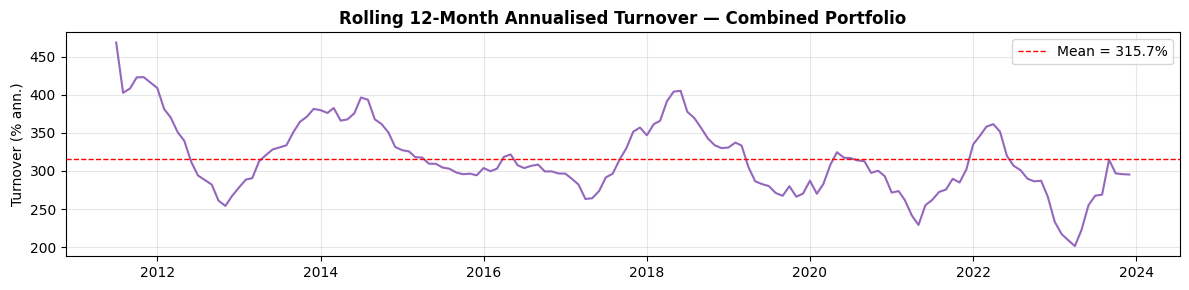

Saved: data/combined_turnover.png


In [34]:
monthly_turnover = results_train['n_buys'] / results_train['n_stocks'].clip(lower=1)
ann_turnover     = monthly_turnover.mean() * 12

print("=== TURNOVER ANALYSIS ===")
print(f"Avg monthly turnover rate : {monthly_turnover.mean():.1%}")
print(f"Annualised turnover       : {ann_turnover:.1%}")
print(f"Implied one-way trades/yr : {ann_turnover * results_train['n_stocks'].mean():.0f} stock-changes")
print()
print("Comparison (from notebook 05):")
print("  Momentum  : ~120-150% ann. turnover (high churn)")
print("  Low-Vol   : ~60-80% ann. turnover")
print(f"  Combined  : {ann_turnover:.0%} ann. turnover (should be between the two)")

# Rolling turnover plot
fig, ax = plt.subplots(figsize=(12, 3))
roll_to = monthly_turnover.rolling(12).mean() * 12 * 100  # annualised %
ax.plot(results_train['holding_month'], roll_to.values, lw=1.5, color='#9467bd')
ax.axhline(roll_to.mean(), color='red', lw=1, linestyle='--', label=f'Mean = {roll_to.mean():.1f}%')
ax.set_title('Rolling 12-Month Annualised Turnover — Combined Portfolio', fontweight='bold')
ax.set_ylabel('Turnover (% ann.)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/combined_turnover.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/combined_turnover.png")

---
## Cell 15 — Notebook summary

Run this at the end to get a clean printout of all key numbers.

In [35]:
print("=" * 65)
print("NOTEBOOK 07 — FINAL SUMMARY")
print("=" * 65)
print()
print("STRATEGY: Equal-weighted Z-score combination")
print("          12m-skip-1m Momentum + 90d Low-Volatility")
print("UNIVERSE: FTSE 250 (point-in-time, survivorship-bias-free)")
print("COSTS:    Corwin-Schultz spread + 0.5% stamp duty on buys")
print()
print("-" * 65)
print("TRAINING PERIOD (2010–2023) — NET OF COSTS")
print("-" * 65)
print_metrics(metrics_train)

if len(results_holdout) > 0:
    print()
    print("-" * 65)
    print("HOLDOUT PERIOD (2024–2025) — NET OF COSTS")
    print("-" * 65)
    print_metrics(metrics_holdout)

print()
print("FILES SAVED")
print("  data/combined_equity_curve_training.png")
print("  data/combined_equity_curve_full.png")
print("  data/combined_drawdown.png")
print("  data/combined_turnover.png")
print("  data/signal_correlation.png")
print("  data/combined_strategy_comparison.csv")
print("  data/working/results_combined_net.parquet")

NOTEBOOK 07 — FINAL SUMMARY

STRATEGY: Equal-weighted Z-score combination
          12m-skip-1m Momentum + 90d Low-Volatility
UNIVERSE: FTSE 250 (point-in-time, survivorship-bias-free)
COSTS:    Corwin-Schultz spread + 0.5% stamp duty on buys

-----------------------------------------------------------------
TRAINING PERIOD (2010–2023) — NET OF COSTS
-----------------------------------------------------------------
  Strategy          : Combined (Mom + LowVol) — Training
  Period (months)   : 161
  Ann. return (net) : 10.8%
  Ann. volatility   : 12.2%
  Sharpe ratio      : 0.84
  Ann. alpha (net)  : 4.6%  ***
  t-stat alpha (NW) : 2.87
  Beta              : 0.73
  Max drawdown      : -24.2%
  Calmar ratio      : 0.44
  Information ratio : 0.31
  --- Benchmark ---
  Benchmark ann.ret : 8.1%
  Benchmark Sharpe  : 0.54
  (* p<.10  ** p<.05  *** p<.01)

-----------------------------------------------------------------
HOLDOUT PERIOD (2024–2025) — NET OF COSTS
------------------------------

In [4]:
import os
for root, dirs, files in os.walk('../data'):
    for f in files:
        if f.endswith('.parquet'):
            print(os.path.join(root, f))

../data\holdout_locked\benchmark_holdout.parquet
../data\holdout_locked\equities_holdout.parquet
../data\holdout_locked\sonia_holdout.parquet
../data\raw\benchmark.parquet
../data\raw\master_tickers.parquet
../data\raw\membership_panel.parquet
../data\raw\membership_snapshots.parquet
../data\raw\sonia.parquet
../data\raw\bid_ask\ba_chunk_000.parquet
../data\raw\bid_ask\ba_chunk_001.parquet
../data\raw\bid_ask\ba_chunk_002.parquet
../data\raw\bid_ask\ba_chunk_003.parquet
../data\raw\bid_ask\ba_chunk_004.parquet
../data\raw\bid_ask\ba_chunk_005.parquet
../data\raw\bid_ask\ba_chunk_006.parquet
../data\raw\bid_ask\ba_chunk_007.parquet
../data\raw\bid_ask\ba_chunk_008.parquet
../data\raw\bid_ask\ba_chunk_009.parquet
../data\raw\bid_ask\ba_chunk_010.parquet
../data\raw\bid_ask\ba_chunk_011.parquet
../data\raw\bid_ask\ba_chunk_012.parquet
../data\raw\bid_ask\ba_chunk_013.parquet
../data\raw\bid_ask\ba_chunk_014.parquet
../data\raw\bid_ask\ba_chunk_015.parquet
../data\raw\bid_ask\ba_chunk_016.

In [6]:
membership = pd.read_parquet('../data/raw/membership_snapshots.parquet')
print(membership.columns.tolist())
print(membership.head(3))

['ticker', 'field', 'Index Member', 'Percent Weight', 'snapshot_date']
      ticker              field Index Member  Percent Weight snapshot_date
0  MCX Index  INDX_MWEIGHT_HIST  1218069D LN        0.092829    2010-01-29
1  MCX Index  INDX_MWEIGHT_HIST  1334987D LN        0.156177    2010-01-29
2  MCX Index  INDX_MWEIGHT_HIST  1561649D LN        0.301515    2010-01-29


In [7]:
print("=== BENCHMARK ===")
print(benchmark.columns.tolist())
print(benchmark.head(3))
print()
print("=== SONIA ===")
print(sonia.columns.tolist())
print(sonia.head(3))
print()
print("=== BID_ASK sample ===")
print(ba.columns.tolist())
print(ba.head(3))
print()
print("=== MONTHLY SIGNALS ===")
print(monthly.columns.tolist())
print(monthly.head(3))

=== BENCHMARK ===


NameError: name 'benchmark' is not defined

In [8]:
import glob
import pandas as pd

membership = pd.read_parquet('../data/raw/membership_snapshots.parquet')
benchmark  = pd.read_parquet('../data/working/benchmark_train.parquet')
sonia      = pd.read_parquet('../data/working/sonia_train.parquet')
ba_chunks  = sorted(glob.glob('../data/raw/bid_ask/ba_chunk_*.parquet'))
ba         = pd.concat([pd.read_parquet(f) for f in ba_chunks], ignore_index=True)
monthly    = pd.read_parquet('../data/working/monthly_signals.parquet')

print("=== MEMBERSHIP ===")
print(membership.columns.tolist())
print(membership.head(2))
print()
print("=== BENCHMARK ===")
print(benchmark.columns.tolist())
print(benchmark.head(2))
print()
print("=== SONIA ===")
print(sonia.columns.tolist())
print(sonia.head(2))
print()
print("=== BID_ASK ===")
print(ba.columns.tolist())
print(ba.head(2))
print()
print("=== MONTHLY SIGNALS ===")
print(monthly.columns.tolist())
print(monthly.head(2))

=== MEMBERSHIP ===
['ticker', 'field', 'Index Member', 'Percent Weight', 'snapshot_date']
      ticker              field Index Member  Percent Weight snapshot_date
0  MCX Index  INDX_MWEIGHT_HIST  1218069D LN        0.092829    2010-01-29
1  MCX Index  INDX_MWEIGHT_HIST  1334987D LN        0.156177    2010-01-29

=== BENCHMARK ===
['ticker', 'date', 'field', 'value']
      ticker       date                        field    value
0  MCX Index 2009-07-01                      PX_LAST  7506.71
1  MCX Index 2009-07-01  TOT_RETURN_INDEX_GROSS_DVDS  7506.71

=== SONIA ===
['ticker', 'date', 'field', 'value']
          ticker       date    field   value
0  SONIO/N Index 2009-07-01  PX_LAST  0.4195
1  SONIO/N Index 2009-07-02  PX_LAST  0.4160

=== BID_ASK ===
['ticker', 'date', 'field', 'value']
               ticker        date field  value
0  1218069D LN Equity  2010-01-04   BID  280.0
1  1218069D LN Equity  2010-01-04   ASK  293.7

=== MONTHLY SIGNALS ===
['ticker', 'month', 'date', 'CUR_MKT

In [17]:
print("Monthly signals months (first 5):")
print(sorted(monthly['month'].unique())[:5])
print()
print("Membership months (first 5):")
print(sorted(membership['month'].unique())[:5])
print()
print("Monthly dtype :", monthly['month'].dtype)
print("Membership dtype:", membership['month'].dtype)

Monthly signals months (first 5):
[Timestamp('2009-07-01 00:00:00'), Timestamp('2009-08-01 00:00:00'), Timestamp('2009-09-01 00:00:00'), Timestamp('2009-10-01 00:00:00'), Timestamp('2009-11-01 00:00:00')]

Membership months (first 5):
[Timestamp('2010-01-01 00:00:00'), Timestamp('2010-02-01 00:00:00'), Timestamp('2010-03-01 00:00:00'), Timestamp('2010-04-01 00:00:00'), Timestamp('2010-05-01 00:00:00')]

Monthly dtype : datetime64[us]
Membership dtype: datetime64[us]


In [18]:
print("Membership tickers (first 3):")
print(membership['ticker'].head(3).tolist())
print()
print("Monthly signals tickers (first 3):")
print(monthly['ticker'].head(3).tolist())

Membership tickers (first 3):
['1218069D LN', '1334987D LN', '1561649D LN']

Monthly signals tickers (first 3):
['0966088D LN Equity', '0966088D LN Equity', '1218069D LN Equity']


In [19]:
membership['ticker'] = membership['ticker'] + ' Equity'

print("Fixed membership tickers (first 3):")
print(membership['ticker'].head(3).tolist())
print()

# Verify overlap
monthly_tickers = set(monthly['ticker'].unique())
membership_tickers = set(membership['ticker'].unique())
overlap = monthly_tickers & membership_tickers
print(f"Ticker overlap: {len(overlap)} tickers match")

Fixed membership tickers (first 3):
['1218069D LN Equity', '1334987D LN Equity', '1561649D LN Equity']

Ticker overlap: 635 tickers match
